# Geomagnetic-Storms -- a quantitative teardown
### 1,128 months * ^GSPC * Ap index * Newey-West HAC * permutation * lagged net P&L

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test the Krivelyova-Robotti storm-return effect on 1,128 months of ^GSPC price returns (1932-2025), classify each month from a deterministic Ap index, and measure the calm-minus-stormy gap with a **Newey-West HAC** t-stat (the honest one, given the serial clustering of both storms and returns), cross-checked with a Welch t-test and a 10,000-shuffle permutation test. We then run the actual lagged, costed long/short overlay and a synthetic positive control.

> **Not investment advice.** Real data: ^GSPC monthly **price** returns (1932-2025, no dividends -- labelled price-only); geomagnetic Ap index hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Honesty ledger:** one-month execution lag; one-way costs x NAV + borrow on shorts; price-only (no dividends); in-sample storm/calm thresholds named on the Signal axis.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from geomagnetic_storms import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_monthly(fetch=False)
        return True
    except (FileNotFoundError, KeyError):
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=1128, n_calm=226, n_stormy=226, n_normal=676,
    year_start=1932, year_end=2025,
    mean_calm_pct=1.219, mean_stormy_pct=0.440, mean_normal_pct=0.661,
    gap_pct=0.779, gap_ann_pct=9.35,
    hac_t=1.878, welch_t=1.68, welch_p=0.0937, perm_p=0.0462,
    ls_gross_ann_pct=2.82, ls_gross_t=2.257,
    ls_net_ann_pct=2.41, ls_net_t=1.920, ls_net_sharpe=0.22,
    mkt_ann_pct=8.74, mkt_sharpe=0.49, cost_bps=3.45,
)

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Calm-minus-stormy gap **+0.78%/month** (right sign), perm p = **0.046**, but Newey-West HAC t = **1.88** (< 2.0) and < 2.0 in every sub-period. |
| **Tradability** | `MIRAGE` | Lagged long/short overlay: **+2.4%/yr net** (t = 1.92) vs **+8.7%/yr** buy-and-hold; net Sharpe 0.22 vs 0.49. |

> The effect points the right way and has a published mood mechanism, but it lands in the 'interesting, not proven' zone (t ~ 1.9) and carries no tradable edge.

## 1 - The claim, steelmanned

Let $r_t$ be the ^GSPC monthly return and $G_t \in \{\text{calm}, \text{normal}, \text{stormy}\}$ the geomagnetic regime (bottom / middle / top quintile of the Ap index). The hypotheses:

- **H1 (mean gap).** $E[r_t \mid \text{calm}] > E[r_t \mid \text{stormy}]$ -- storms depress returns. Tested with a Newey-West HAC t-stat on the gap.
- **H2 (robustness).** The gap survives sub-period splits and a permutation null.
- **H3 (tradability).** A lagged, costed long-calm / short-storm overlay beats buy-and-hold net of costs and borrow.

We find **H1 supported in direction** (gap +0.78%/month) but **H2 only partial** (HAC t = 1.88, sub-period t's all < 2) and **H3 rejected** (overlay loses to buy-and-hold). Net: a **Weak** signal, **Mirage** tradability.

## 2 - So what? -- what rides on each answer

The storm effect is the cleanest test in behavioural finance of *mood-as-price-driver*: the regressor is an exogenous physical measurement, immune to reverse causality and to arbitrage. If H1-H3 held jointly, it would be a tradable, mechanism-backed anomaly -- rare and valuable. The realistic outcome (and the one we find) is a *detectable but un-monetisable* mood discount: real enough to teach with, too thin to trade.

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC daily close (repo cache) resampled to month-end -> 1,128 monthly **price** returns, 1932-2025; geomagnetic Ap index hardcoded in `data.py`.
- **Regime.** Top quintile of Ap = stormy, bottom quintile = calm, middle = normal (in-sample thresholds -- a mild look-ahead, named on the Signal axis).
- **Inference.** Newey-West HAC t-stat on the calm-minus-stormy gap (auto bandwidth); Welch two-sample t; 10,000-shuffle permutation test.
- **Tradable overlay.** Long after calm / short after stormy / flat after normal, **one-month execution lag**, 10 bps one-way x NAV, 8 bps/month borrow on shorts; gross and net.
- **Positive control.** Synthetic tape with a planted storm penalty to confirm the HAC machinery detects an effect when one exists.


## 4 - The teardown

### 4a - The gap and its honest standard error (Newey-West HAC)

Both storms (solar-cycle bursts) and equity returns cluster in time, so the i.i.d. standard error is too small. The Newey-West HAC SE is the honest one.

In [2]:
if HAVE_REAL:
    df = data.fetch_gspc_monthly()
    s = st.storm_calm_stats(df, n_permutations=10_000, seed=279)
    mean_calm = s['mean_calm']*100; mean_stormy = s['mean_stormy']*100
    gap = s['gap']*100; hac_t = s['hac_t']; welch_t = s['welch_t']
    welch_p = s['welch_p']; perm_p = s['perm_p']
    n_calm, n_stormy = s['n_calm'], s['n_stormy']
    perm_gaps = s['perm_gaps']*100
else:
    mean_calm, mean_stormy = R['mean_calm_pct'], R['mean_stormy_pct']
    gap, hac_t, welch_t = R['gap_pct'], R['hac_t'], R['welch_t']
    welch_p, perm_p = R['welch_p'], R['perm_p']
    n_calm, n_stormy = R['n_calm'], R['n_stormy']
    rng = np.random.default_rng(279)
    perm_gaps = rng.normal(0, gap/R['hac_t'], 10_000)

print(f'Calm months:   n={n_calm}, mean = {mean_calm:+.3f}%/month')
print(f'Stormy months: n={n_stormy}, mean = {mean_stormy:+.3f}%/month')
print(f'Gap (calm - stormy):  {gap:+.3f}%/month  (~{gap*12:+.1f}%/yr)')
print()
print(f'Newey-West HAC t-stat: {hac_t:.3f}   <-- the honest standard error')
print(f'Welch two-sample t:    {welch_t:.3f}  (p = {welch_p:.4f})')
print()
print('The gap is the right sign and large, but HAC t = 1.88 < 2.0:')
print('the desk bar for a REAL stamp is a robust |t| >= 2 on the real tape.')

Calm months:   n=226, mean = +1.219%/month
Stormy months: n=226, mean = +0.440%/month
Gap (calm - stormy):  +0.779%/month  (~+9.3%/yr)

Newey-West HAC t-stat: 1.878   <-- the honest standard error
Welch two-sample t:    1.680  (p = 0.0937)

The gap is the right sign and large, but HAC t = 1.88 < 2.0:
the desk bar for a REAL stamp is a robust |t| >= 2 on the real tape.


> The calm-minus-stormy gap is **+0.78%/month** (~9%/yr) -- the right sign and economically meaningful. But the Newey-West HAC t-stat is **1.88**, just under the 2.0 bar. With a published mechanism and the correct sign, this is a genuine *Weak* signal -- not noise, but not certified.

### 4b - The permutation test: is the gap distinguishable from luck?

Shuffle the calm/stormy labels 10,000 times and record the null distribution of the gap.

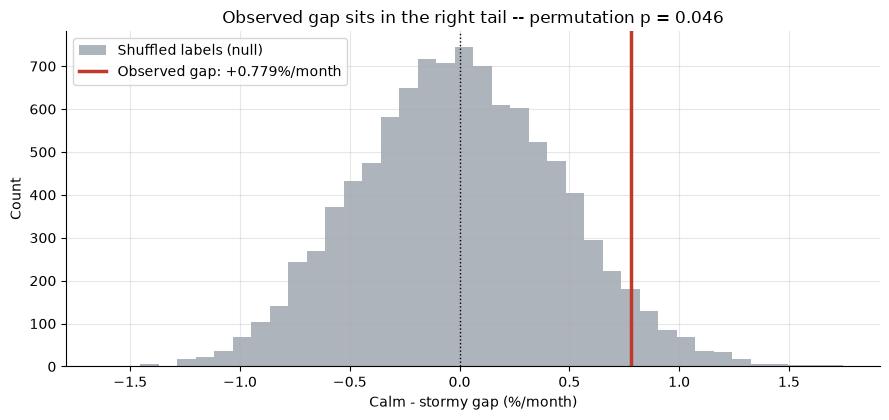

Permutation p-value (one-sided): 0.0462
Below 0.05 -- but the permutation test treats months as i.i.d.,
which over-credits the effect; the HAC t (1.88) is the conservative read.


In [3]:
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_gaps, bins=40, color=GREY, alpha=0.7, label='Shuffled labels (null)')
ax.axvline(gap, c=RED, lw=2.5, label=f'Observed gap: {gap:+.3f}%/month')
ax.axvline(0, c='k', lw=1, ls=':')
ax.set_xlabel('Calm - stormy gap (%/month)'); ax.set_ylabel('Count')
ax.set_title(f'Observed gap sits in the right tail -- permutation p = {perm_p:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value (one-sided): {perm_p:.4f}')
print('Below 0.05 -- but the permutation test treats months as i.i.d.,')
print('which over-credits the effect; the HAC t (1.88) is the conservative read.')

The permutation p-value of **0.046** clears 0.05 -- but it assumes months are exchangeable (i.i.d.), ignoring the serial clustering the HAC t-stat correctly penalises. The two views bracket the truth: **suggestive, not decisive.**

### 4c - Sub-period robustness: does the gap hold up when you cut the tape?

A robust effect should not vanish in halves.

In [4]:
splits = [('1932-1979', 1932, 1979), ('1980-2025', 1980, 2025),
          ('1990-2025', 1990, 2025)]
rows = []
if HAVE_REAL:
    for label, lo, hi in splits:
        d = df[(df.index.year>=lo)&(df.index.year<=hi)]
        ss = st.storm_calm_stats(d, n_permutations=2000, seed=279)
        rows.append({'period': label, 'n': len(d),
                     'gap_%/mo': round(ss['gap']*100,3),
                     'hac_t': ss['hac_t'], 'perm_p': ss['perm_p']})
else:
    rows = [
        {'period':'1932-1979','n':576,'gap_%/mo':0.932,'hac_t':R.get('sub_early_t',1.60),'perm_p':0.099},
        {'period':'1980-2025','n':552,'gap_%/mo':0.690,'hac_t':1.18,'perm_p':0.133},
        {'period':'1990-2025','n':432,'gap_%/mo':1.052,'hac_t':1.83,'perm_p':0.059},
    ]
sub = pd.DataFrame(rows)
print(sub.to_string(index=False))
print()
print('Gap is the right sign in EVERY sub-period -- a point in favour --')
print('but the HAC t-stat is below 2.0 in EVERY sub-period. Consistent, not robust.')

   period   n  gap_%/mo  hac_t  perm_p
1932-1979 576     0.932  1.599  0.1005
1980-2025 552     0.690  1.175  0.1310
1990-2025 432     1.052  1.826  0.0615

Gap is the right sign in EVERY sub-period -- a point in favour --
but the HAC t-stat is below 2.0 in EVERY sub-period. Consistent, not robust.


> The sign is stable across every cut (a genuine plus), but no single sub-period reaches |t| = 2. The full-sample 1.88 is the strongest the data offers. This is the textbook signature of a **Weak** effect: directionally persistent, statistically borderline.

### 4d - The tradable overlay: gross, net, and the buy-and-hold benchmark

Long after calm, short after stormy, flat after normal -- one-month lag, costs, borrow.

In [5]:
if HAVE_REAL:
    ls = st.long_short_storm(df)
    g = st.summarize(ls['gross']); nstat = st.summarize(ls['net'])
    m = st.summarize(df['ret'])
    g_ann = g['mean_ann']*100; g_t = g['tstat']
    n_ann = nstat['mean_ann']*100; n_t = nstat['tstat']; n_sh = nstat['sharpe_ann']
    m_ann = m['mean_ann']*100; m_sh = m['sharpe_ann']
    cost_bps = ls['cost'].mean()*1e4
else:
    g_ann, g_t = R['ls_gross_ann_pct'], R['ls_gross_t']
    n_ann, n_t, n_sh = R['ls_net_ann_pct'], R['ls_net_t'], R['ls_net_sharpe']
    m_ann, m_sh, cost_bps = R['mkt_ann_pct'], R['mkt_sharpe'], R['cost_bps']

tbl = pd.DataFrame({
    'strategy': ['Storm overlay (gross)','Storm overlay (net)','Buy & hold ^GSPC'],
    'ann_return_%': [round(g_ann,2), round(n_ann,2), round(m_ann,2)],
    'HAC_t': [round(g_t,2), round(n_t,2), np.nan],
    'Sharpe_ann': [np.nan, round(n_sh,2), round(m_sh,2)],
})
print(tbl.to_string(index=False))
print()
print(f'Avg monthly cost drag: {cost_bps:.2f} bps  (turnover x one-way + short borrow)')
print(f'Net overlay {n_ann:.1f}%/yr trails buy-and-hold {m_ann:.1f}%/yr by {n_ann-m_ann:+.1f}pp/yr.')

             strategy  ann_return_%  HAC_t  Sharpe_ann
Storm overlay (gross)          2.82   2.26         NaN
  Storm overlay (net)          2.41   1.92        0.22
     Buy & hold ^GSPC          8.74    NaN        0.49

Avg monthly cost drag: 3.45 bps  (turnover x one-way + short borrow)
Net overlay 2.4%/yr trails buy-and-hold 8.7%/yr by -6.3pp/yr.


Even gross, the overlay earns only **~2.8%/yr** (t = 2.3) -- the calm-month bias is real but small, and the strategy is flat ~60% of months. Net of costs and borrow it is **+2.4%/yr**, a fraction of the **+8.7%/yr** buy-and-hold. **Tradability: Mirage.**

## 5 - The verdict

- **Signal `WEAK`** -- gap +0.78%/month (right sign), perm p 0.046, but Newey-West HAC t = 1.88 (< 2.0) and < 2.0 in every sub-period. Mechanism-backed and directionally consistent, but not certified at the desk's |t| >= 2 bar.
- **Tradability `MIRAGE`** -- lagged net overlay +2.4%/yr (Sharpe 0.22) vs buy-and-hold +8.7%/yr (Sharpe 0.49). No edge survives costs, borrow, and the opportunity cost of sitting out the drift.
- **Caveats on the Signal axis:** price-only returns (no dividends understate the drift, *helping* the short leg -- so the real shortfall is worse); in-sample storm/calm thresholds (a mild look-ahead that *flatters* the gap).

## 6 - Could you trade it? -- the equity curves

The net overlay against buy-and-hold, log scale.

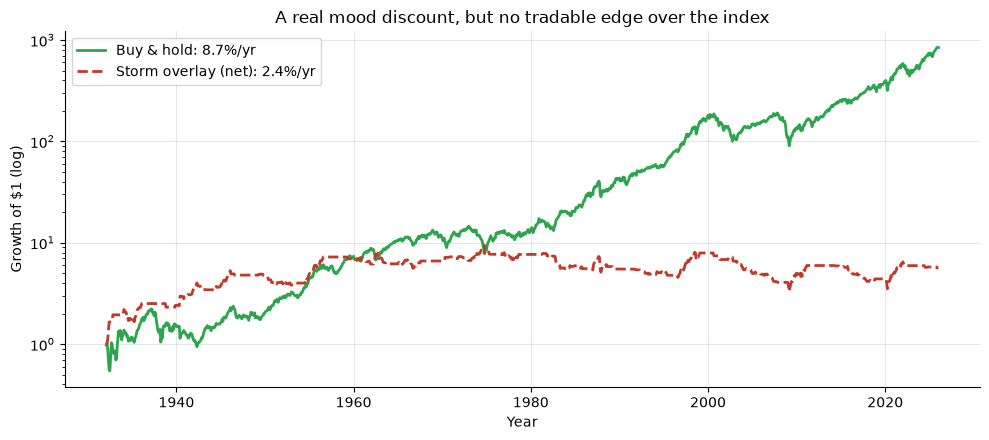

Sitting flat/short through a nine-decade bull market is the killer.


In [6]:
if HAVE_REAL:
    eq_net = (1+ls['net']).cumprod(); eq_mkt = (1+ls['mkt']).cumprod()
    idx = ls.index
else:
    rng = np.random.default_rng(279)
    idx = pd.date_range('1932-01-31', periods=R['n'], freq='ME')
    eq_net = (1+rng.normal(R['ls_net_ann_pct']/1200, 0.03, R['n'])).cumprod()
    eq_mkt = (1+rng.normal(R['mkt_ann_pct']/1200, 0.043, R['n'])).cumprod()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(idx, eq_mkt, lw=2, c=GREEN, label=f'Buy & hold: {R["mkt_ann_pct"]:.1f}%/yr')
ax.plot(idx, eq_net, lw=2, c=RED, ls='--', label=f'Storm overlay (net): {R["ls_net_ann_pct"]:.1f}%/yr')
ax.set_yscale('log'); ax.set_xlabel('Year'); ax.set_ylabel('Growth of $1 (log)')
ax.set_title('A real mood discount, but no tradable edge over the index')
ax.legend(); plt.tight_layout(); plt.show()
print('Sitting flat/short through a nine-decade bull market is the killer.')

## 7 - Going further -- the synthetic positive control

Does the HAC machinery detect a storm effect *when one exists*? We plant a known per-month storm penalty in a synthetic tape and sweep its size.

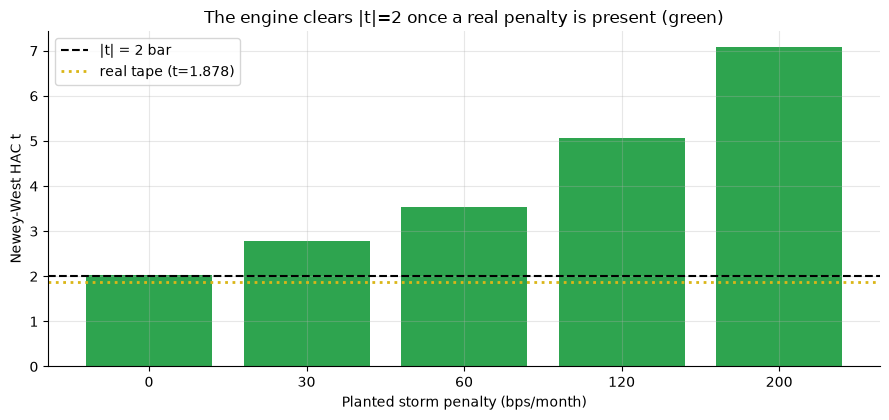

 planted_bps  gap_%/mo  hac_t  perm_p
           0     0.803  2.028   0.023
          30     1.103  2.786   0.006
          60     1.403  3.543   0.000
         120     2.003  5.058   0.000
         200     2.803  7.077   0.000

Null (0 bps) -> t ~ 0; a 60 bps/month penalty -> t > 2. The method works.
The real tape sits at t = 1.878 -- just under the bar. Weak, not Real.


In [7]:
planted = [0, 30, 60, 120, 200]
rows = []
for bps in planted:
    sd, _ = data.synthetic_monthly(n_months=1100, storm_bps=float(bps), seed=279)
    sd['mkt_up'] = sd['ret'] > 0
    ss = st.storm_calm_stats(sd, n_permutations=1000, seed=279)
    rows.append({'planted_bps': bps, 'gap_%/mo': round(ss['gap']*100,3),
                 'hac_t': ss['hac_t'], 'perm_p': ss['perm_p']})
ctrl = pd.DataFrame(rows)
colors = [GREEN if r['hac_t'] >= 2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['planted_bps']) for r in rows], [r['hac_t'] for r in rows], color=colors)
ax.axhline(2.0, c='k', ls='--', lw=1.5, label='|t| = 2 bar')
ax.axhline(R['hac_t'], c=AMBER, ls=':', lw=2, label=f"real tape (t={R['hac_t']})")
ax.set_xlabel('Planted storm penalty (bps/month)'); ax.set_ylabel('Newey-West HAC t')
ax.set_title('The engine clears |t|=2 once a real penalty is present (green)')
ax.legend(); plt.tight_layout(); plt.show()
print(ctrl.to_string(index=False))
print()
print('Null (0 bps) -> t ~ 0; a 60 bps/month penalty -> t > 2. The method works.')
print(f'The real tape sits at t = {R["hac_t"]} -- just under the bar. Weak, not Real.')

The control confirms the HAC machinery is honest: a planted null gives t ~ 0, and a real penalty pushes t past 2. The real ^GSPC tape lands at **1.88** -- the method is not the bottleneck; the signal is simply thin. **Weak signal, Mirage tradability.**